In [40]:
import pandas as pd

In [41]:
df = pd.read_parquet("../data/datasets/training_dataset.parquet")

In [42]:
df.columns

Index(['prediction_time', 'price', 'month', 'weekday', 'hour', 'lag_24h',
       'lag_48h', 'lag_1w', 'rolling_24h_mean', 'rolling_24h_std',
       'rolling_24h_mean_diff', 'rolling_1w_mean', 'rolling_1w_std',
       'rolling_1w_mean_diff', 'hours_ahead', 'target', 'target_time',
       'target_hour', 'target_weekday', 'target_is_holiday', 'hour_sin',
       'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos',
       'week_hour_sin', 'week_hour_cos', 'demand_forecast', 'demand_lag_24h',
       'demand_lag_48h', 'demand_lag_1w', 'demand_rolling_24h_mean',
       'demand_rolling_24h_std', 'demand_rolling_24h_mean_diff',
       'demand_rolling_1w_mean', 'demand_rolling_1w_std',
       'demand_rolling_1w_mean_diff', 'wind_generation_forecast',
       'solarpv_generation_forecast', 'solarth_generation_forecast',
       'interconnection_balance_francia', 'interconnection_balance_portugal',
       'net_interconnection_balance', 'net_interconnection_balance_lag_24h',
       'net

In [43]:
df.shape

(624708, 55)

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 624708 entries, 0 to 624707
Data columns (total 55 columns):
 #   Column                                             Non-Null Count   Dtype              
---  ------                                             --------------   -----              
 0   prediction_time                                    624708 non-null  datetime64[us, UTC]
 1   price                                              624708 non-null  float64            
 2   month                                              624708 non-null  int32              
 3   weekday                                            624708 non-null  int32              
 4   hour                                               624708 non-null  int32              
 5   lag_24h                                            624708 non-null  float64            
 6   lag_48h                                            624708 non-null  float64            
 7   lag_1w                                             624708 

In [45]:
df.isna().sum().max()

np.int64(0)

In [46]:
coverage = (
    pd.DataFrame({
        "missing": df.isna().sum(),
        "coverage_pct": (1 - df.isna().mean()) * 100
    })
    .sort_values("coverage_pct")
)

print(coverage.head(20))

                       missing  coverage_pct
prediction_time              0         100.0
price                        0         100.0
month                        0         100.0
weekday                      0         100.0
hour                         0         100.0
lag_24h                      0         100.0
lag_48h                      0         100.0
lag_1w                       0         100.0
rolling_24h_mean             0         100.0
rolling_24h_std              0         100.0
rolling_24h_mean_diff        0         100.0
rolling_1w_mean              0         100.0
rolling_1w_std               0         100.0
rolling_1w_mean_diff         0         100.0
hours_ahead                  0         100.0
target                       0         100.0
target_time                  0         100.0
target_hour                  0         100.0
target_weekday               0         100.0
target_is_holiday            0         100.0


In [47]:
df.head(20)

,prediction_time,price,month,weekday,hour,lag_24h,lag_48h,lag_1w,rolling_24h_mean,rolling_24h_std,...,net_interconnection_balance_rolling_24h_mean,net_interconnection_balance_rolling_24h_std,net_interconnection_balance_rolling_24h_mean_diff,mechanism_adjustment_price,nuclear_generation_forecast,hydro_generation_forecast,renewable_generation_forecast,net_demand,residual_domestic_load,renewable_ratio
0,2023-01-08 23:00:00+00:00,5.1,1,6,23,7.0,53.42,61.38,21.839583,13.302359,...,-252.116667,214.389765,-13.152083,-0.48,1294.675,690.97500,14777.250,5294.333333,5820.733333,0.736227
1,2023-01-08 23:00:00+00:00,5.1,1,6,23,7.0,53.42,61.38,21.839583,13.302359,...,-299.965625,214.549406,-12.258333,1.21,1356.175,831.70000,12629.500,10945.000000,11138.950000,0.535727
2,2023-01-08 23:00:00+00:00,5.1,1,6,23,7.0,53.42,61.38,21.839583,13.302359,...,-324.302083,137.662464,-14.445833,3.96,1758.325,1837.70000,9869.500,22368.750000,22400.500000,0.306143
3,2023-01-08 23:00:00+00:00,5.1,1,6,23,7.0,53.42,61.38,21.839583,13.302359,...,-323.723958,196.265126,-2.562500,2.20,1535.500,1179.16250,14794.550,16298.700000,16570.075000,0.475812
4,2023-01-08 23:00:00+00:00,5.1,1,6,23,7.0,53.42,61.38,21.839583,13.302359,...,-334.352083,141.355107,2.641667,4.76,1761.275,1280.48750,10393.500,14023.083333,14669.458333,0.425674
5,2023-01-08 23:00:00+00:00,5.1,1,6,23,7.0,53.42,61.38,21.839583,13.302359,...,-330.161458,138.728963,-5.859375,3.91,1763.750,1440.95000,10028.250,19332.833333,19724.058333,0.341549
6,2023-01-08 23:00:00+00:00,5.1,1,6,23,7.0,53.42,61.38,21.839583,13.302359,...,-327.612500,191.793951,-3.888542,2.20,1577.750,1116.18125,16644.050,14426.950000,15022.700000,0.535678
7,2023-01-08 23:00:00+00:00,5.1,1,6,23,7.0,53.42,61.38,21.839583,13.302359,...,-320.137500,191.017481,2.358333,0.94,1634.575,977.06250,19480.100,11082.233333,11894.233333,0.637389
8,2023-01-08 23:00:00+00:00,5.1,1,6,23,7.0,53.42,61.38,21.839583,13.302359,...,-268.593750,215.265718,-16.477083,0.84,1310.175,679.18750,14366.500,5278.500000,5799.875000,0.731306
9,2023-01-08 23:00:00+00:00,5.1,1,6,23,7.0,53.42,61.38,21.839583,13.302359,...,-306.652083,180.053732,7.982292,0.50,1673.575,951.82500,18605.450,10691.716667,11556.641667,0.635060


<Axes: xlabel='target_hour'>

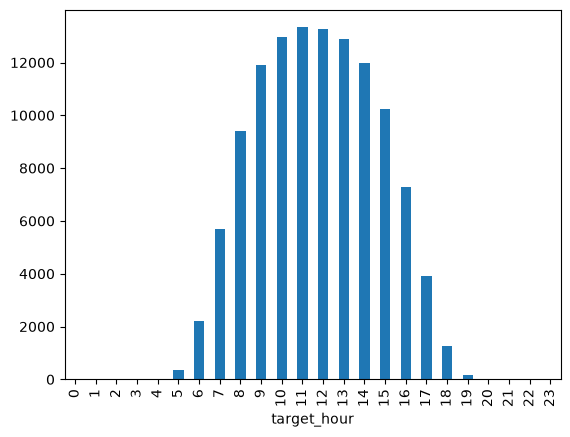

In [48]:
df.groupby("target_hour")["solarpv_generation_forecast"].mean().plot.bar()

In [49]:
forecast_cols = [
    "wind_generation_forecast",
    "solarpv_generation_forecast",
    "solarth_generation_forecast",
    "hydro_generation_forecast",
    "nuclear_generation_forecast",
]

corrs = (
    df[
        forecast_cols
        + ["available_generation_capacity"]
    ]
    .corr()["available_generation_capacity"]
    .sort_values(ascending=False)
)

print(corrs)

KeyError: "['available_generation_capacity'] not in index"